# 743. Network Delay Time

You are given a network of n nodes, labeled from **1 to n**. You are also given times, a list of travel times as directed edges **times[i] = (ui, vi, wi)**, where ui is the source node, **vi** is the target node, and wi is the time it takes for a signal to travel from source to target.

We will send a signal from a given node k. Return the minimum time it takes for all the **n nodes** to receive the signal. If it is impossible for all the n nodes to receive the signal, return **-1**.

## Example 1:

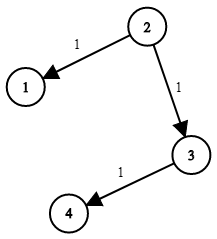

Input: times = [[2,1,1],[2,3,1],[3,4,1]], n = 4, k = 2
Output: 2

## Example 2:

Input: times = [[1,2,1]], n = 2, k = 1
Output: 1

## Example 3:

Input: times = [[1,2,1]], n = 2, k = 2
Output: -1

# Specification


## Intro

O problema exige encontrar o tempo mínimo para que um sinal enviado de um nó de origem k alcance todos os outros n nós em um grafo direcionado com arestas ponderadas (tempos). O "delay" total da rede será definido pelo caminho mais curto mais longo a partir de k para qualquer outro nó; se algum nó for inacessível, a rede nunca será totalmente notificada.

['from','to','distance]

## Functional definition

```py
from typing import List, Dict, Tuple
import heapq

class Solution:
    def networkDelayTime(self, times: List[List[int]], n: int, k: int) -> int:
        # A função principal orquestrará a busca do caminho mais curto.
        # k é o nó de origem (1-indexado).
        # n é o número total de nós.
        pass
```

## Edges cases

- Grafo desconectado, o sinal nunca chega em alguns nós retornar -1, ou nó sem aresta de  chegada
- Nó de origem sem arestas de saida
- O algortimo deve lidar bem com ciclos
- Caminhos multiplos para o mesmo nó temos que fazer uma heuristica de pegar o menor caminho


# Plan

- Poderiamos usar DFS para chegar para explorar todos os caminho  possiveis porem isso poderia dar um  crescimento extremamente grande em  grafos complexos sendo pouco eficiente
- Podemos tenar usar o algortimo  de  dijkstra, uma vez que há muito tempo é considerado um dos melhores algortimos para encontrar o caminho mais curto em um grafo da origem ao destino
- O dijkstra chega na complexidade de O(E log V)
- Podemos usar uma fila de prioridade para tambem obter o menor custo

## Exemple

times = [[2,1,1],[2,3,1],[3,4,1]] , n=4 (4 nos) e origem k = 2

### Step1 - Lista de adjeacencia   

Transformar em lista de adjeacencia para ficar mais facil de pegar os vizinhos no algoritimo

*origem : [dest,dist]

{
    2:[(1,1),(3,1)]
    3:[(4,1)]
}

### Step2 - Caso base

Se iniciarmos a heap com o caso base onde a tupla representa (tempo_acumulado, nó) 

minheap = [(0,2)]

Heap  Nó Ação


Heap            Nó      Ação
[(0,2)]         2       o tempo aqui é 0, colocamos os vizinhos na heap (1,1) e (2,3), sendo 1,1 o menor 

[(1,1),(2,3)]   1       1 não tem vizinhos, então a distancia é o 1.

[(1, 3)]        3       o tempo ate aqui é 1, colocamos os vizinhos na heap [((acc+1),4)] = [(2,4)]

[(2,4)]         4       4 não tem vizinhos, a distancia  final é 2 

dist = {2:0, 1:0, 3:1, 4:1}

# Descobrir o maior

max(dist.values()) O(n)


In [ ]:
from typing import List
import heapq
from collections import defaultdict

# A função principal orquestrará a busca do caminho mais curto.
# k é o nó de origem (1-indexado).
# n é o número total de nós.

class Solution:
    def networkDelayTime(self, times: List[List[int]], n: int, k: int) -> int:
        adjacency_list = defaultdict(list)
        for source, destination, time in times:
            adjacency_list[source].append((destination,time))

        min_heap = heapq.heapify([(0,k)])
        
        #Node
        shortest_paths = {}

        while min_heap: # O(log E)
            current_time, current_node = heapq.heappop(min_heap)

            if current_node in shortest_paths:
                continue
            
            shortest_paths[current_node] = current_time
            #Exploramos todos os vizinhos
            for neighbor, weight in adjacency_list[current_node]: #O(E)
                 heapq.heappush(min_heap,(weight,neighbor)) # O(log E)

        if len(shortest_paths) == n:
              return max(shortest_paths.values())  #O(n)
        
        return -1 
    
# O(E log V) 
# Onde V é o numero de vértices 
# Onde E é o numero de arestas


        